<a href="https://colab.research.google.com/github/chidi-u/quant-finance-projects/blob/main/us-treasury-portfolio-construction/us_treasury_portfolio_construction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
# 1. importing 5 relevant libraries
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.optimize import linprog, brentq

In [59]:
# just confirming library version
print("pandas", pd.__version__)
print("numpy", np.__version__)

pandas 2.2.3
numpy 2.1.3


In [60]:
# 3: load the prices
PRICE_DATE = "2026-09-29"          # FedInvest price date
FILE_NAME = "securityprice(1).csv"

prices = pd.read_csv(FILE_NAME, header=None,
                     names=["cusip", "security_type", "rate", "maturity_date",
                            "call_date", "buy", "sell", "end_of_day"])

print(prices.head())
print("Number of securities:", len(prices))

       cusip      security_type  rate maturity_date  call_date        buy  \
0  912797SA6  MARKET BASED BILL   0.0    10/01/2026        NaN   0.000000   
1  912797VK0  MARKET BASED BILL   0.0    10/06/2026        NaN  99.925139   
2  912797UJ4  MARKET BASED BILL   0.0    10/08/2026        NaN  99.903250   
3  912797VL8  MARKET BASED BILL   0.0    10/13/2026        NaN  99.849500   
4  912797UK1  MARKET BASED BILL   0.0    10/15/2026        NaN  99.828000   

        sell  end_of_day  
0  99.978889         0.0  
1  99.924944         0.0  
2  99.903000         0.0  
3  99.849111         0.0  
4  99.827556         0.0  
Number of securities: 463


In [61]:
# 4: clean csv file
price_date = pd.to_datetime(PRICE_DATE)

# Before: for every security type in the csv file
print(prices["security_type"].value_counts())

# 1. Keep only bills, notes and bonds (drops TIPS and FRNs)
is_fixed = prices["security_type"].str.contains("BILL|NOTE|BOND", na=False)
bonds = prices[is_fixed].copy()

# 2. Turn maturity dates from text into real dates
bonds["maturity_date"] = pd.to_datetime(bonds["maturity_date"], format="%m/%d/%Y")

# 3. Drop anything maturing within a month
bonds = bonds[bonds["maturity_date"] > price_date + pd.Timedelta(days=30)]

# 4. Drop any row missing a buy or sell price
bonds = bonds[(bonds["buy"] > 0) & (bonds["sell"] > 0)]

# After: print final clean data
print(bonds["security_type"].value_counts())
print("Total remaining:", len(bonds))

security_type
MARKET BASED NOTE    241
MARKET BASED BOND    112
TIPS                  53
MARKET BASED BILL     49
MARKET BASED FRN       8
Name: count, dtype: int64
security_type
MARKET BASED NOTE    216
MARKET BASED BOND    110
MARKET BASED BILL     40
Name: count, dtype: int64
Total remaining: 366


In [62]:
same_price = bonds["buy"] == bonds["sell"]
print(pd.crosstab(bonds["security_type"], same_price))

col_0              False  True 
security_type                  
MARKET BASED BILL     40      0
MARKET BASED BOND    109      1
MARKET BASED NOTE    201     15


In [63]:
# Step 5: identify/select the benchmark (on-the-run 3yr US Treasury Bond in this case)
url = "https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/accounting/od/auctions_query"

params = {
    "fields": "cusip,security_type,security_term,auction_date,issue_date,maturity_date",
    "filter": f"security_type:eq:Note,security_term:eq:3-Year,issue_date:lte:{PRICE_DATE}",
    "sort": "-auction_date",
    "page[size]": 1,
}

response = requests.get(url, params=params)
auction = response.json()["data"][0]
print(auction)

benchmark_cusip = auction["cusip"]
benchmark = bonds[bonds["cusip"] == benchmark_cusip]
print(benchmark)

years = (benchmark["maturity_date"].iloc[0] - price_date).days / 365.25
print("Years to maturity:", round(years, 2))

{'cusip': '91282CRL7', 'security_type': 'Note', 'security_term': '3-Year', 'auction_date': '2026-09-08', 'issue_date': '2026-09-15', 'maturity_date': '2029-09-15'}
         cusip      security_type     rate maturity_date  call_date      buy  \
190  91282CRL7  MARKET BASED NOTE  0.04375    2029-09-15        NaN  98.1875   

        sell  end_of_day  
190  98.1875         0.0  
Years to maturity: 2.96


In [64]:
# 6: build cash flows

def coupon_dates(maturity, settle):
   # Returns the future coupon dates, and the last coupon date already paid
    dates = []
    k = 0
    while True:
        d = maturity - pd.DateOffset(months=6 * k)
        if maturity.is_month_end:
            d = d + pd.offsets.MonthEnd(0)
        if d <= settle:
            last_coupon = d
            break
        dates.append(d)
        k += 1
    return sorted(dates), last_coupon


def cash_flows(bond, settle):
    maturity = bond["maturity_date"]
    if "BILL" in bond["security_type"]:
        return [(maturity, 100.0)], 0.0
    half_coupon = bond["rate"] * 100 / 2
    dates, last_coupon = coupon_dates(maturity, settle)
    flows = [(d, half_coupon) for d in dates]
    flows[-1] = (dates[-1], half_coupon + 100)
    next_coupon = dates[0]
    accrued = half_coupon * (settle - last_coupon).days / (next_coupon - last_coupon).days
    return flows, accrued

all_flows = {}
accrued_list = []

for i, bond in bonds.iterrows():
    flows, accrued = cash_flows(bond, price_date)
    all_flows[bond["cusip"]] = flows
    accrued_list.append(accrued)

bonds["accrued"] = accrued_list
bonds["price_paid"] = bonds["buy"] + bonds["accrued"]
bonds["price_bid"] = bonds["sell"] + bonds["accrued"]


# Check: benchmark cash flows: Prints each payment date (`pay_date`) and amount for the benchmark note.
for pay_date, amount in all_flows[benchmark_cusip]:
    print(pay_date.date(), round(amount, 4))

print(bonds.loc[bonds["cusip"] == benchmark_cusip, ["buy", "accrued", "price_paid"]])

# confirmation that cash flows for all selected bonds are filtered out
print(len(all_flows), len(bonds))

2027-03-15 2.1875
2027-09-15 2.1875
2028-03-15 2.1875
2028-09-15 2.1875
2029-03-15 2.1875
2029-09-15 102.1875
         buy   accrued  price_paid
190  98.1875  0.169199   98.356699
366 366


In [65]:
# 7: calculating yield to maturity (YTM) for every bond

def times_in_periods(bond, settle):
    # Time from settle to each payment, counted in half-years
    maturity = bond["maturity_date"]
    if "BILL" in bond["security_type"]:
        return [(maturity - settle).days / 182.5]
    dates, last_coupon = coupon_dates(maturity, settle)
    first = (dates[0] - settle).days / (dates[0] - last_coupon).days
    return [first + i for i in range(len(dates))]


def price_at_yield(y, amounts, times):
    # Value today of all payments, discounted at yield y (twice-a-year compounding)
    return sum(cf / (1 + y / 2) ** t for cf, t in zip(amounts, times))


def ytm(bond, price, settle):
    # Finds the yield that makes the payments worth exactly the price
    amounts = [amount for pay_date, amount in all_flows[bond["cusip"]]]
    times = times_in_periods(bond, settle)

    def gap(y):
        return price_at_yield(y, amounts, times) - price

    return brentq(gap, -0.05, 0.50)

ytm_list = []
ytm_bid_list = []

for i, bond in bonds.iterrows():
    ytm_list.append(ytm(bond, bond["price_paid"], price_date))
    ytm_bid_list.append(ytm(bond, bond["price_bid"], price_date))

bonds["ytm"] = ytm_list
bonds["ytm_bid"] = ytm_bid_list


### confirmation Check: benchmark yield vs Treasury's published 3-year yield for PRICE_DATE - just a reference check to confirm code works right
# Under 10 bps: correct, 10–30 bps: recheck the cash flows and dates, 30+ bps: there's a bug. Fix it before continuing.
TREASURY_CSV = "https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rates.csv/2026/all?type=daily_treasury_yield_curve&field_tdr_date_value=2026&page&_format=csv"

curve = pd.read_csv(TREASURY_CSV)
published_3y = curve.loc[pd.to_datetime(curve["Date"]) == price_date, "3 Yr"].iloc[0]

bench = bonds[bonds["cusip"] == benchmark_cusip]
my_3y = bench["ytm_bid"].iloc[0] * 100

print("Treasury published 3 Yr:", published_3y, "%")
print("My benchmark yield:     ", round(my_3y, 3), "%")
print("Difference (bps):       ", round((my_3y - published_3y) * 100, 1))

Treasury published 3 Yr: 4.98 %
My benchmark yield:      5.041 %
Difference (bps):        6.1


In [66]:
# 8: calculating modified duration for every bond

def modified_duration(bond, y, settle):
    amounts = [amount for pay_date, amount in all_flows[bond["cusip"]]]
    times = times_in_periods(bond, settle)
    pvs = [cf / (1 + y / 2) ** t for cf, t in zip(amounts, times)]
    price = sum(pvs)
    macaulay = sum(t * pv for t, pv in zip(times, pvs)) / price / 2
    return macaulay / (1 + y / 2)


duration_list = []
for i, bond in bonds.iterrows():
    duration_list.append(modified_duration(bond, bond["ytm"], price_date))

bonds["duration"] = duration_list

# Benchmark duration, stored to be used in Step 12
benchmark_duration = bonds.loc[bonds["cusip"] == benchmark_cusip, "duration"].iloc[0]
print("Benchmark duration:", round(benchmark_duration, 3))

Benchmark duration: 2.735


In [67]:
### 9: Liquidity filter: Removes any security whose Buy − Sell gap (bid/ask spread) is more than 5 cents per $100, since a wide gap means the security is costly to trade and its price may be stale. Retain the benchmark bond irrespective.
# 9: liquidity filter
MAX_GAP_CENTS = 5

bonds["gap_cents"] = (bonds["buy"] - bonds["sell"]) * 100

keep = (bonds["gap_cents"] <= MAX_GAP_CENTS) | (bonds["cusip"] == benchmark_cusip)
removed = bonds[~keep]
bonds = bonds[keep].copy()

# Check: how many were removed, and which ones
print("Removed:", len(removed), "| Remaining:", len(bonds))
print(removed[["cusip", "security_type", "maturity_date", "gap_cents"]])


Removed: 43 | Remaining: 323
         cusip      security_type maturity_date  gap_cents
292  912810FA1  MARKET BASED BOND    2027-08-15    25.0000
293  912810FB9  MARKET BASED BOND    2027-11-15    21.8750
294  912810FE3  MARKET BASED BOND    2028-08-15    21.8750
295  912810FF0  MARKET BASED BOND    2028-11-15    18.7500
296  912810FG8  MARKET BASED BOND    2029-02-15    20.3125
297  912810FJ2  MARKET BASED BOND    2029-08-15    23.4375
298  912810FM5  MARKET BASED BOND    2030-05-15    20.3125
299  912810FP8  MARKET BASED BOND    2031-02-15    17.1875
300  912810FT0  MARKET BASED BOND    2036-02-15    15.6250
301  912810PT9  MARKET BASED BOND    2037-02-15    10.9375
302  912810PU6  MARKET BASED BOND    2037-05-15    14.0625
303  912810PW2  MARKET BASED BOND    2038-02-15    12.5000
304  912810PX0  MARKET BASED BOND    2038-05-15     9.3750
305  912810QA9  MARKET BASED BOND    2039-02-15    10.9375
306  912810QB7  MARKET BASED BOND    2039-05-15     7.8125
307  912810QC5  MARKET BASE

In [68]:
### 10: Optimization setup: Maximizes portfolio yield subject to: weights add to 1, no negative weights, and portfolio duration at or below a limit. The limit is given when the function is called (Steps 11, 12 and 15).
# Step 10: optimization setup (the Solver dialog)
def optimize(duration_limit):
    yields = bonds["ytm"].values
    durations = bonds["duration"].values
    n = len(bonds)

    result = linprog(
        c=-yields,                              # objective: maximize yield
        A_ub=[durations], b_ub=[duration_limit], # portfolio duration <= limit
        A_eq=[np.ones(n)], b_eq=[1],             # weights add to 1
        bounds=[(0, None)] * n,                  # no weight below 0
        method="highs",
    )
    return result

In [69]:
### 11: Optimize at the benchmark's duration: finds the highest-yielding portfolio
### with duration no higher than the benchmark's, checks the result, and reports
### the yield pickup over the benchmark.
# 11: Optimize at the benchmark's duration
benchmark_yield = bonds.loc[bonds["cusip"] == benchmark_cusip, "ytm"].iloc[0]

def report(result, duration_limit):
    weights = result.x
    port_yield = (weights * bonds["ytm"].values).sum()
    port_duration = (weights * bonds["duration"].values).sum()
    yield_pickup_bps = (port_yield - benchmark_yield) * 10000

    # Checks
    print("Solver success:    ", result.success)
    print("Weights add to:    ", round(weights.sum(), 6))
    print("Portfolio duration:", round(port_duration, 3), "| limit:", round(duration_limit, 3))

    # Results
    print("Portfolio yield:   ", round(port_yield * 100, 3), "%")
    print("Benchmark yield:   ", round(benchmark_yield * 100, 3), "%")
    print("Yield pickup:      ", round(yield_pickup_bps, 1), "bps")

    # Bonds selected
    held = weights > 0.0001
    holdings = bonds.loc[held, ["cusip", "security_type", "maturity_date", "ytm", "duration"]].copy()
    holdings["weight"] = weights[held]
    print(holdings)
    return holdings

result = optimize(benchmark_duration)
holdings = report(result, benchmark_duration)

Solver success:     True
Weights add to:     1.0
Portfolio duration: 2.735 | limit: 2.735
Portfolio yield:    5.044 %
Benchmark yield:    5.041 %
Yield pickup:       0.3 bps
         cusip      security_type maturity_date       ytm   duration    weight
183  91282CQZ7  MARKET BASED NOTE    2029-07-15  0.050324   2.578806  0.982504
350  912810UL0  MARKET BASED BOND    2045-05-15  0.056703  11.485318  0.017496


In [70]:
# 12: Build the buy order
AMOUNT = 100_000     # total to invest, in dollars
ROUND_TO = 1_000     # broker's minimum step for face value

order = holdings.copy()
order["price_paid"] = bonds.loc[order.index, "price_paid"]
order["dollars"] = AMOUNT * order["weight"]
order["face_value"] = (order["dollars"] / (order["price_paid"] / 100) / ROUND_TO).round() * ROUND_TO
order["cost"] = order["face_value"] * order["price_paid"] / 100

print(order[["cusip", "maturity_date", "weight", "price_paid", "face_value", "cost"]])
print("Total cost:", round(order["cost"].sum(), 2))

         cusip maturity_date    weight  price_paid  face_value          cost
183  91282CQZ7    2029-07-15  0.982504   98.508152    100000.0  98508.152174
350  912810UL0    2045-05-15  0.017496   94.205163      2000.0   1884.103261
Total cost: 100392.26


In [71]:
# 13 (a): summary table
summary = pd.DataFrame({
    "CUSIP": order["cusip"],
    "Type": order["security_type"].str.replace("MARKET BASED ", "").str.title(),
    "Maturity": order["maturity_date"].dt.date,
    "Face value ($)": order["face_value"],
    "Cost ($)": order["cost"].round(2),
    "Weight (%)": (order["cost"] / order["cost"].sum() * 100).round(2),
    "YTM (%)": (order["ytm"] * 100).round(3),
    "Duration": order["duration"].round(3),
})
print(summary.to_string(index=False))

summary.to_excel("portfolio_summary.xlsx", index=False)

    CUSIP Type   Maturity  Face value ($)  Cost ($)  Weight (%)  YTM (%)  Duration
91282CQZ7 Note 2029-07-15        100000.0  98508.15       98.12    5.032     2.579
912810UL0 Bond 2045-05-15          2000.0   1884.10        1.88    5.670    11.485


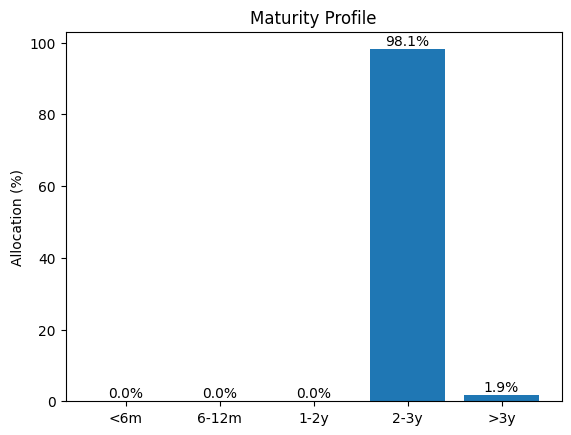

Total: 100.0 %


In [72]:
# 13 (b): maturity profile chart
years = (order["maturity_date"] - price_date).dt.days / 365.25
buckets = pd.cut(years, bins=[0, 0.5, 1, 2, 3, 100],
                 labels=["<6m", "6-12m", "1-2y", "2-3y", ">3y"])
profile = order["cost"].groupby(buckets, observed=False).sum() / order["cost"].sum() * 100

plt.bar(profile.index.astype(str), profile.values)
for i, v in enumerate(profile.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha="center")
plt.ylabel("Allocation (%)")
plt.title("Maturity Profile")
plt.show()

print("Total:", round(profile.sum(), 1), "%")

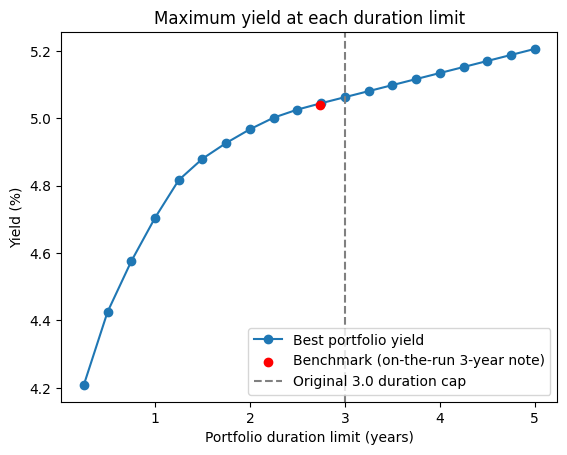

Duration 0.25: yield 4.209% | yield pickup -83.2 bps
Duration 0.50: yield 4.425% | yield pickup -61.6 bps
Duration 0.75: yield 4.576% | yield pickup -46.5 bps
Duration 1.00: yield 4.705% | yield pickup -33.6 bps
Duration 1.25: yield 4.817% | yield pickup -22.4 bps
Duration 1.50: yield 4.880% | yield pickup -16.1 bps
Duration 1.75: yield 4.927% | yield pickup -11.4 bps
Duration 2.00: yield 4.967% | yield pickup -7.3 bps
Duration 2.25: yield 5.002% | yield pickup -3.9 bps
Duration 2.50: yield 5.026% | yield pickup -1.5 bps
Duration 2.75: yield 5.045% | yield pickup 0.4 bps
Duration 3.00: yield 5.063% | yield pickup 2.2 bps
Duration 3.25: yield 5.081% | yield pickup 4.0 bps
Duration 3.50: yield 5.098% | yield pickup 5.8 bps
Duration 3.75: yield 5.116% | yield pickup 7.5 bps
Duration 4.00: yield 5.134% | yield pickup 9.3 bps
Duration 4.25: yield 5.152% | yield pickup 11.1 bps
Duration 4.50: yield 5.170% | yield pickup 12.9 bps
Duration 4.75: yield 5.188% | yield pickup 14.7 bps
Duration 5.

In [73]:
# 14: Plot yield vs duration
limits = np.arange(0.25, 5.01, 0.25)
best_yields = [(-optimize(d).fun) * 100 for d in limits]

plt.plot(limits, best_yields, marker="o", label="Best portfolio yield")
plt.scatter(benchmark_duration, benchmark_yield * 100, color="red", zorder=3,
            label="Benchmark (on-the-run 3-year note)")
plt.axvline(3.0, color="grey", linestyle="--", label="Original 3.0 duration cap")
plt.xlabel("Portfolio duration limit (years)")
plt.ylabel("Yield (%)")
plt.title("Maximum yield at each duration limit")
plt.legend()
plt.savefig("yield_vs_duration.png", dpi=150, bbox_inches="tight")
plt.show()

for d, y in zip(limits, best_yields):
    print(f"Duration {d:.2f}: yield {y:.3f}% | yield pickup {(y - benchmark_yield * 100) * 100:.1f} bps")

In [74]:
# *** just showing bond with highest YTM from price sheet
print(bonds.loc[bonds["ytm"].idxmax(), ["cusip", "security_type", "maturity_date", "ytm", "duration"]])

cusip                      912810SJ8
security_type      MARKET BASED BOND
maturity_date    2049-08-15 00:00:00
ytm                         0.057214
duration                   15.447708
Name: 373, dtype: object
